# Socioeconomic Development and Environmental Performance

## Research Question

**How is socioeconomic development associated with environmental performance across countries?**

## Research Questions

1. Is economic prosperity associated with environmental performance?

2. Do countries with higher educational participation show higher environmental performance?

3. How is urbanization associated with environmental performance, and does this relationship differ across environmental dimensions such as air quality, waste management, and environmental health?

4. Are employment and unemployment rates associated with environmental performance?

5. Which countries perform substantially better or worse environmentally than their economic prosperity might suggest?

6. Which socioeconomic indicators show the strongest relationships with environmental performance?


## Predictive Modeling Questions

1. Can socioeconomic indicators be used to predict a country's environmental performance?

2. How do different regression models compare in predicting environmental performance?

## 1. Setup

Importing the libraries required for data processing, visualization, machine learning, model evaluation, and SHAP-based explainability.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import shap

## 2. Data Loading and Initial Inspection

### 2.1 Environmental Performance Index (EPI)

The EPI dataset is loaded and initially inspected to understand its structure, dimensions, and available environmental indicators.

In [2]:
epi = pd.read_excel("data/epi/epi2026results2026-07-07.xlsx", sheet_name="data")

In [3]:
epi.head(5)

,iso,country,EPI.new,HLT.new,AIR.new,PMD.new,HFD.new,OZD.new,NOD.new,COE.new,...,GRP.6,GRP.7,GRP.8,GRP.9,region,groupname,GDP,GPC,POP,LDA
0,AFG,Afghanistan,33.14,24.66,24.44,40.18,4.86,20.28,65.61,49.72,...,SWZ,TKM,UGA,CAF,Southern Asia,Landlocked Developing Countries,83.677383,1962.070438,42.647492,652230.0
1,ALB,Albania,49.22,48.67,37.37,32.07,38.77,60.79,60.26,62.46,...,SRB,ROU,HUN,BIH,Eastern Europe,Central European Initiative,51.443601,18950.592789,2.714617,27400.0
2,DZA,Algeria,42.74,50.96,54.83,14.37,100.00,29.89,47.85,44.50,...,SAU,EGY,OMN,ARE,Greater Middle East,Arab League,725.711643,15501.919700,46.814308,2381740.0
3,AGO,Angola,39.46,24.93,19.45,18.77,17.19,26.62,35.63,38.66,...,KIR,BFA,UGA,NPL,Sub-Saharan Africa,Least Developed Countries,337.255561,8901.887366,37.885849,1246700.0
4,ATG,Antigua & Barbuda,48.04,66.07,68.52,54.22,80.05,100.00,34.12,82.50,...,BHS,KNA,SUR,LCA,Latin America & Caribbean,Small Island Developing States,2.754237,29371.637779,0.093772,440.0


In [4]:
epi.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'PMD.new', 'HFD.new',
       'OZD.new', 'NOD.new', 'COE.new',
       ...
       'GRP.6', 'GRP.7', 'GRP.8', 'GRP.9', 'region', 'groupname', 'GDP', 'GPC',
       'POP', 'LDA'],
      dtype='str', length=422)

### 2.2 Selecting Relevant EPI Variables

The original EPI dataset contains 422 columns. For the initial analysis, variables related to overall environmental performance, environmental health, air quality, waste management, and geographical region are selected.

The original dataset is preserved, while the selected variables are stored separately for analysis.

In [5]:
relevant_columns = [
    "iso",
    "country",
    "EPI.new",
    "HLT.new",
    "AIR.new",
    "WMG.new",
    "region"
]

epi_analysis = epi[relevant_columns].copy()

In [6]:
epi_analysis.head()

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region
0,AFG,Afghanistan,33.14,24.66,24.44,56.20,Southern Asia
1,ALB,Albania,49.22,48.67,37.37,91.69,Eastern Europe
2,DZA,Algeria,42.74,50.96,54.83,40.00,Greater Middle East
3,AGO,Angola,39.46,24.93,19.45,43.89,Sub-Saharan Africa
4,ATG,Antigua & Barbuda,48.04,66.07,68.52,49.50,Latin America & Caribbean


### 2.3 Data Quality Check

The selected dataset is examined for its dimensions, data types, missing values, duplicate rows, and country coverage before further analysis.

In [7]:
epi_analysis.shape

(177, 7)

In [8]:
epi_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   iso      177 non-null    str    
 1   country  177 non-null    str    
 2   EPI.new  177 non-null    float64
 3   HLT.new  177 non-null    float64
 4   AIR.new  177 non-null    float64
 5   WMG.new  177 non-null    float64
 6   region   177 non-null    str    
dtypes: float64(4), str(3)
memory usage: 9.8 KB


In [9]:
print("Duplicate rows:", epi_analysis.duplicated().sum())
print("Unique countries:", epi_analysis["country"].nunique())

Duplicate rows: 0
Unique countries: 177


## 3. Socioeconomic Data

### 3.1 GDP per Capita

GDP per capita data from the World Bank is loaded as the first socioeconomic indicator. The first four metadata rows are skipped so that the dataset is read using its actual column headers.

In [10]:
gdp = pd.read_csv("data/world_bank/gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv", skiprows=4)

In [11]:
gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30654.485124,22664.370995,26827.344787,31000.571380,34897.618393,38590.565029,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089515,186.909365,197.367876,225.400456,208.963066,226.836513,...,1529.923080,1553.617944,1508.031525,1351.503167,1560.894626,1675.902524,1571.132704,1628.227289,1722.385620,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,416.871146,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.551510,155.587905,...,1577.203497,1723.114463,2219.412555,2034.437940,2116.938294,2143.072094,1846.246811,1416.228412,1600.058374,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2832.149980,2891.830324,2507.868072,1749.179484,2266.968349,3598.536691,2885.513491,2720.819007,3129.476623,NaN


#### Selecting the Reference Year

The most recent years are examined to determine which provides better data coverage for the analysis.

In [12]:
gdp['2024'].isna().sum()

np.int64(18)

In [13]:
gdp['2025'].isna().sum()

np.int64(32)

The 2024 column contains 18 missing values, compared with 32 in 2025. Therefore, 2024 is selected as the reference year because it provides more complete data coverage.

#### Selecting Relevant Variables

Only the country name, country code, and 2024 GDP per capita values are retained for the analysis. The country code will later be used to match the World Bank data with the EPI dataset.

In [14]:
relevant_gdp_columns = ['Country Name', 'Country Code', '2024']
gdp_analysis = gdp[relevant_gdp_columns].copy()

In [15]:
gdp_analysis.head()

,Country Name,Country Code,2024
0,Aruba,ABW,38590.565029
1,Africa Eastern and Southern,AFE,1628.227289
2,Afghanistan,AFG,416.871146
3,Africa Western and Central,AFW,1416.228412
4,Angola,AGO,2720.819007


#### Matching Countries with the EPI Dataset

World Bank country codes are compared with the ISO codes in the EPI dataset. This ensures that the GDP dataset contains only countries relevant to the environmental analysis and removes aggregate World Bank entries that do not represent individual EPI countries.

In [16]:
mask = gdp_analysis["Country Code"].isin(epi_analysis["iso"])
gdp_matched = gdp_analysis[mask]
gdp_matched

,Country Name,Country Code,2024
2,Afghanistan,AFG,416.871146
4,Angola,AGO,2720.819007
5,Albania,ALB,11374.008578
8,United Arab Emirates,ARE,50273.512624
9,Argentina,ARG,13969.783660
...,...,...,...
257,Vanuatu,VUT,3959.877035
259,Samoa,WSM,5392.877619
262,South Africa,ZAF,6267.186814
263,Zambia,ZMB,1187.109434


In [17]:
epi_analysis[~epi_analysis['iso'].isin(gdp['Country Code'])]

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region
155,TWN,Taiwan,46.02,60.11,48.86,97.88,Asia-Pacific


In [18]:
gdp_matched.isna().sum()

Country Name    0
Country Code    0
2024            0
dtype: int64

**Matching result:** 176 of the 177 EPI countries were successfully matched with the World Bank GDP data. Taiwan (TWN) was the only unmatched country. Among the 176 matched countries, no missing values were found for 2024 GDP per capita.

In [19]:
gdp_matched.rename(columns = {'2024': 'GDP_per_capita'}, inplace=True)

In [20]:
gdp_matched.columns

Index(['Country Name', 'Country Code', 'GDP_per_capita'], dtype='str')

In [21]:
gdp_matched.shape

(176, 3)

**GDP preparation result:** The final GDP dataset contains 176 matched countries and 3 variables. The 2024 GDP per capita values are complete for all matched countries, while Taiwan (TWN) remains unmatched with the World Bank data.

### 3.2 Education

Secondary school enrollment data from the World Bank is used as the education indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [22]:
education = pd.read_csv("data/world_bank/education/API_SE.SEC.ENRR_DS2_en_csv_v2_37594.csv", skiprows = 4)

In [23]:
education.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,137.829788,139.320587,135.124725,123.625908,131.802170,NaN,124.379367,NaN,NaN
1,Africa Eastern and Southern,AFE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,43.254089,43.559410,44.128731,44.682560,45.150532,45.281620,45.155392,45.606079,NaN,NaN
2,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,55.536430,57.357849,NaN,NaN,NaN,NaN,59.613602,NaN,NaN,NaN
3,Africa Western and Central,AFW,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,42.433170,42.714561,43.906269,44.734341,45.567429,45.637299,46.442242,46.300491,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,53.135154,NaN,51.483905,NaN,NaN,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the education indicator.

In [24]:
education[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     75
2021     72
2022     80
2023     74
2024    112
2025    256
dtype: int64

#### Matching Education Data with EPI Countries

The education dataset is filtered using ISO country codes to retain only countries included in the EPI dataset.

In [25]:
education_mask = education['Country Code'].isin(epi_analysis['iso'])
edu_matched = education[education_mask]
edu_matched

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
2,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,55.536430,57.357849,NaN,NaN,NaN,NaN,59.613602,NaN,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,53.135154,NaN,51.483905,NaN,NaN,NaN
5,Albania,ALB,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,97.574370,98.822388,99.015154,95.929447,97.665033,97.322471,96.136877,108.355392,NaN,NaN
8,United Arab Emirates,ARE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102.184448,101.747344,99.163540,103.210663,102.380981,101.944972,102.129725,NaN,NaN
9,Argentina,ARG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,110.377800,109.671242,110.460152,112.376732,115.735779,114.148117,105.574584,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,Vanuatu,VUT,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,59.168800,62.943310,81.955128,134.670675,NaN,NaN,NaN
259,Samoa,WSM,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,105.623169,101.399613,103.789120,103.501178,106.443304,104.535067,104.133481,NaN,NaN,NaN
263,Zambia,ZMB,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.788929,NaN,NaN


In [26]:
epi_analysis[~epi_analysis['iso'].isin(education['Country Code'])]

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region
155,TWN,Taiwan,46.02,60.11,48.86,97.88,Asia-Pacific


In [27]:
edu_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     48
2021     43
2022     53
2023     47
2024     86
2025    168
dtype: int64

#### Reference Year Selection

After matching the education data with the EPI countries, missing values were compared again across recent years. Although 2021 has the highest coverage, 2023 has only four additional missing values while providing more recent information. Therefore, 2023 was selected as the reference year.

In [28]:
relevant_edu_columns = ['Country Name', 'Country Code', '2023']

In [29]:
edu_analysis = edu_matched[relevant_edu_columns].copy()

In [30]:
edu_analysis.head()

,Country Name,Country Code,2023
2,Afghanistan,AFG,59.613602
4,Angola,AGO,51.483905
5,Albania,ALB,96.136877
8,United Arab Emirates,ARE,101.944972
9,Argentina,ARG,105.574584


In [31]:
edu_analysis.rename(columns = {'2023' : 'Secondary_enrollment'}, inplace = True)

In [32]:
edu_analysis.columns

Index(['Country Name', 'Country Code', 'Secondary_enrollment'], dtype='str')

In [33]:
edu_analysis['Secondary_enrollment'].isna().sum()

np.int64(47)

**Education preparation result:** The 2023 secondary school enrollment rate was selected as a balance between data recency and coverage. After matching with the EPI countries, 176 of 177 countries were successfully matched, with Taiwan (TWN) remaining unmatched. Among the matched countries, 47 education values are missing. Missing values are retained at this stage and will be handled after the datasets are merged.

### 3.3 Employment

Employment-to-population ratio data from the World Bank is used as the employment indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [34]:
employment = pd.read_csv('data/world_bank/employment/API_SL.EMP.TOTL.SP.ZS_DS2_en_csv_v2_200.csv', skiprows = 4)

In [35]:
employment.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,63.061750,62.630817,62.092583,60.693848,60.481732,61.172370,63.596635,63.661513,63.677295,NaN
2,Afghanistan,AFG,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.014000,40.466000,38.913000,36.710000,35.800000,32.333000,32.323000,32.408000,32.457000,NaN
3,Africa Western and Central,AFW,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,69.291064,69.054028,68.834907,67.356279,67.954659,69.388089,70.157119,70.104907,70.001283,NaN
4,Angola,AGO,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,63.045000,62.812000,62.644000,61.078000,64.306000,64.619000,64.369000,64.383000,64.236000,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the employment indicator.

In [36]:
employment[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    31
2021    31
2022    32
2023    34
2024    36
2025    36
dtype: int64

#### Matching Employment Data with EPI Countries

The employment dataset is filtered using ISO country codes to retain only countries included in the EPI dataset.

In [37]:
employment_mask = employment['Country Code'].isin(epi_analysis['iso'])
employment_matched = employment[employment_mask]
employment_matched.shape

(176, 71)

In [38]:
employment_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     7
2021     7
2022     8
2023     9
2024    10
2025    10
dtype: int64

#### Reference Year Selection

After matching the employment data with the EPI countries, missing values were compared again across recent years. Although earlier years have slightly fewer missing values, 2024 was selected because it provides more recent information while maintaining high country coverage.

In [39]:
relevant_emp_columns = ['Country Name', 'Country Code', '2024']
emp_analysis = employment_matched[relevant_emp_columns].copy()
emp_analysis.head()

,Country Name,Country Code,2024
2,Afghanistan,AFG,32.408
4,Angola,AGO,64.383
5,Albania,ALB,57.164
8,United Arab Emirates,ARE,76.789
9,Argentina,ARG,57.439


In [40]:
emp_analysis.rename(columns = {'2024' : 'Employment_rate'}, inplace = True)
emp_analysis.columns

Index(['Country Name', 'Country Code', 'Employment_rate'], dtype='str')

In [41]:
emp_analysis['Employment_rate'].isna().sum()

np.int64(10)

**Employment preparation result:** The 2024 employment-to-population ratio was selected as the employment indicator. After matching with the EPI countries, 176 of 177 countries were retained, and 10 employment values are missing. Missing values are kept at this stage and will be handled after the datasets are merged.

### 3.4 Unemployment

Unemployment data from the World Bank is used as the unemployment indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [42]:
unemployment = pd.read_csv('data/world_bank/unemployment/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_33398.csv', skiprows = 4)

In [43]:
unemployment.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.214915,7.244843,7.459106,7.974302,8.407412,7.869470,7.676548,7.571697,7.539233,NaN
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,11.192000,11.187000,11.710000,12.006000,14.100000,14.008000,13.687000,13.351000,NaN
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.284646,4.336100,4.393903,4.799306,4.670761,3.596538,3.203355,3.174915,3.192973,NaN
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.617000,16.602000,16.497000,16.696000,15.799000,14.124000,14.051000,14.020000,14.108000,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the unemployment indicator.

In [44]:
unemployment[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    31
2021    31
2022    32
2023    34
2024    36
2025    36
dtype: int64

#### Matching Unemployment Data with EPI Countries

In [45]:
unemployment_mask = unemployment['Country Code'].isin(epi_analysis['iso'])
unemployment_matched = unemployment[unemployment_mask]

In [46]:
unemployment_matched.shape

(176, 71)

In [47]:
unemployment_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     7
2021     7
2022     8
2023     9
2024    10
2025    10
dtype: int64

#### Reference Year Selection

After matching the unemployment data with the EPI countries, missing values were compared again across recent years. Although earlier years have slightly fewer missing values, 2024 was selected because it provides more recent information while maintaining high country coverage.

In [48]:
relevant_unemp_columns = ['Country Name', 'Country Code', '2024']

In [49]:
unemp_analysis = unemployment_matched[relevant_unemp_columns].copy()

In [50]:
unemp_analysis.rename(columns = {'2024' : 'Unemployment'}, inplace = True)

In [51]:
unemp_analysis.head()

,Country Name,Country Code,Unemployment
2,Afghanistan,AFG,13.687
4,Angola,AGO,14.020
5,Albania,ALB,10.689
8,United Arab Emirates,ARE,2.160
9,Argentina,ARG,7.150


In [52]:
unemp_analysis['Unemployment'].isna().sum()

np.int64(10)

**Unemployment preparation result:** The 2024 unemployment rate was selected as the unemployment indicator. After matching with the EPI countries, 176 of 177 countries were retained, and 10 unemployment values are missing. Missing values are kept at this stage and will be handled after the datasets are merged.

### 3.5 Urban Population

Urban population data from the World Bank is used as the urbanization indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [53]:
urban_population = pd.read_csv('data/world_bank/urban_population/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_33901.csv', skiprows = 4)

In [54]:
urban_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,59.023670,59.072800,59.212271,59.432359,59.723340,60.075491,...,62.776849,62.536764,62.288276,62.002884,61.927534,61.881166,61.835149,61.790940,61.748525,NaN
1,Africa Eastern and Southern,AFE,Urban population (% of total population),SP.URB.TOTL.IN.ZS,14.640371,14.867730,15.107367,15.353899,15.607152,15.872246,...,35.282987,35.714718,36.097331,36.488322,36.908543,37.360578,37.772301,38.241441,38.702140,NaN
2,Afghanistan,AFG,Urban population (% of total population),SP.URB.TOTL.IN.ZS,8.122551,8.389595,8.662664,8.942709,9.231134,9.529343,...,24.835282,24.999165,25.143726,25.262210,25.347862,25.393925,25.473053,25.700735,25.940164,NaN
3,Africa Western and Central,AFW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,13.946480,14.468419,15.017383,15.592318,16.190616,16.814048,...,48.761009,49.332676,49.905469,50.492321,51.089419,51.700103,52.302109,52.878824,53.477205,NaN
4,Angola,AGO,Urban population (% of total population),SP.URB.TOTL.IN.ZS,10.387104,10.810545,11.207060,11.581720,11.945180,12.308095,...,65.085053,65.873214,66.663782,67.456827,68.252416,69.050619,69.851503,70.655138,71.461592,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the urban population indicator.

In [55]:
urban_population[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    1
2021    1
2022    1
2023    1
2024    1
2025    1
dtype: int64

#### Matching Urban Population Data with EPI Countries

The urban population dataset is filtered using ISO country codes to retain only countries included in the EPI dataset.

In [56]:
urban_mask = urban_population['Country Code'].isin(epi_analysis['iso'])
urban_matched = urban_population[urban_mask]

In [57]:
urban_matched.shape

(176, 71)

In [58]:
urban_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    0
2021    0
2022    0
2023    0
2024    0
2025    0
dtype: int64

#### Reference Year Selection

After matching the urban population data with the EPI countries, no missing values were found across the examined recent years. The year 2024 was selected to maintain consistency with the other socioeconomic indicators used in the analysis.

In [59]:
relevant_urban_columns = ['Country Name', 'Country Code', '2024']
urban_analysis = urban_matched[relevant_urban_columns].copy()

In [60]:
urban_analysis.rename(columns={'2024': 'Urban Population'}, inplace=True)

In [61]:
urban_analysis.shape

(176, 3)

In [62]:
urban_analysis['Urban Population'].isna().sum()

np.int64(0)

**Urban population preparation result:** The 2024 urban population rate was selected as the urbanization indicator. After matching with the EPI countries, 176 of 177 countries were retained, with no missing urban population values.

## 4. Data Integration

The prepared socioeconomic datasets are merged with the EPI dataset using ISO country codes. This creates a single country-level dataset containing environmental performance and development indicators for subsequent analysis.

### 4.1 Merging the Datasets

The prepared datasets are merged sequentially using country codes. The EPI dataset is used as the base, while the socioeconomic indicators are added one by one. After each merge, the dataset dimensions are checked to ensure that no unexpected country loss occurs.

In [63]:
merged_data = pd.merge(epi_analysis, gdp_analysis, left_on = 'iso', right_on = 'Country Code')

In [64]:
merged_data.head()

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region,Country Name,Country Code,2024
0,AFG,Afghanistan,33.14,24.66,24.44,56.20,Southern Asia,Afghanistan,AFG,416.871146
1,ALB,Albania,49.22,48.67,37.37,91.69,Eastern Europe,Albania,ALB,11374.008578
2,DZA,Algeria,42.74,50.96,54.83,40.00,Greater Middle East,Algeria,DZA,5752.990767
3,AGO,Angola,39.46,24.93,19.45,43.89,Sub-Saharan Africa,Angola,AGO,2720.819007
4,ATG,Antigua & Barbuda,48.04,66.07,68.52,49.50,Latin America & Caribbean,Antigua and Barbuda,ATG,23059.833070


In [65]:
merged_data.rename(columns={'2024': 'GDP'}, inplace=True)

In [66]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)   

In [67]:
merged_data = pd.merge(merged_data, edu_analysis, left_on = 'iso', right_on = 'Country Code')

In [68]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [69]:
merged_data = pd.merge(merged_data, emp_analysis, left_on = 'iso', right_on = 'Country Code')

In [70]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [71]:
merged_data = pd.merge(merged_data, unemp_analysis, left_on = 'iso', right_on = 'Country Code')

In [72]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [73]:
merged_data = pd.merge(merged_data, urban_analysis  , left_on = 'iso', right_on = 'Country Code')

In [74]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

### 4.2 Final Dataset Check

After integrating all selected indicators, the final dataset is inspected for its dimensions, column structure, and missing values before proceeding to exploratory data analysis.

In [75]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   iso                   176 non-null    str    
 1   country               176 non-null    str    
 2   EPI.new               176 non-null    float64
 3   HLT.new               176 non-null    float64
 4   AIR.new               176 non-null    float64
 5   WMG.new               176 non-null    float64
 6   region                176 non-null    str    
 7   GDP                   176 non-null    float64
 8   Secondary_enrollment  129 non-null    float64
 9   Employment_rate       166 non-null    float64
 10  Unemployment          166 non-null    float64
 11  Urban Population      176 non-null    float64
dtypes: float64(9), str(3)
memory usage: 16.6 KB


In [76]:
merged_data[['Secondary_enrollment', 'Employment_rate', 'Unemployment']].isna().any(axis = 1).sum()

np.int64(55)

#### Missing Value Strategy

Missing values are retained at this stage rather than removing entire observations. During exploratory analysis, each relationship will use the available observations for the relevant variables, preserving as much country-level information as possible. Missing-value imputation will be handled separately during the machine learning preprocessing stage.

## 5. Exploratory Data Analysis

This section explores the relationships between socioeconomic development and environmental performance across countries, following the research questions defined at the beginning of the analysis.

### 5.1 Economic Prosperity and Environmental Performance

**Research Question:** Is economic prosperity associated with environmental performance?

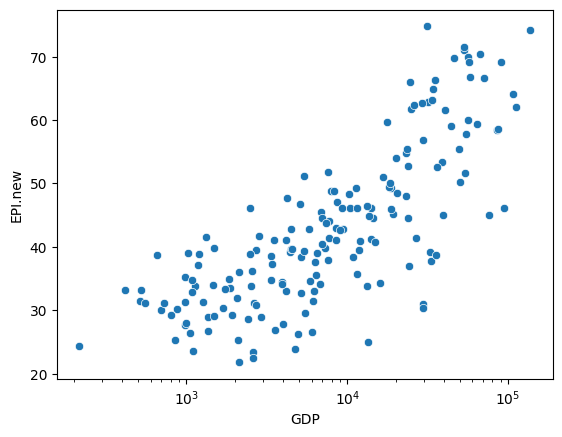

In [77]:
sns.scatterplot(x = 'GDP', y = 'EPI.new', data = merged_data)
plt.xscale('log')

In [78]:
merged_data[['GDP', 'EPI.new']].corr()

,GDP,EPI.new
GDP,1.000000,0.719201
EPI.new,0.719201,1.000000


In [79]:
np.log(merged_data['GDP']).corr(merged_data['EPI.new'])

np.float64(0.7765363900260518)

#### Findings

A clear positive association is observed between economic prosperity and environmental performance. The Pearson correlation between GDP per capita and EPI score is 0.719, indicating that countries with higher income levels tend to have higher environmental performance.

Because GDP per capita is strongly right-skewed, a logarithmic scale was used to better represent differences across income levels. After applying the log transformation, the correlation with EPI increased to 0.777, suggesting that the relationship is more linear when GDP is considered on a logarithmic scale.

These results indicate a strong association between economic prosperity and environmental performance, but they do not imply that higher GDP directly causes better environmental outcomes.

### 5.2 Education and Environmental Performance

**Research Question:** Do countries with higher educational participation show higher environmental performance?

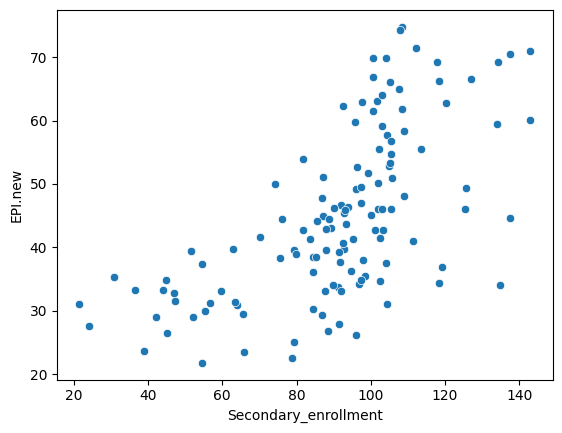

In [80]:
sns.scatterplot(x = 'Secondary_enrollment', y = 'EPI.new', data = merged_data)
plt.show()

In [81]:
merged_data[['Secondary_enrollment', 'EPI.new']].corr()

,Secondary_enrollment,EPI.new
Secondary_enrollment,1.000000,0.632583
EPI.new,0.632583,1.000000


#### Findings

Secondary school enrollment shows a positive association with environmental performance. The Pearson correlation between secondary enrollment and EPI score is 0.633, indicating a moderately strong positive relationship.

Countries with higher secondary enrollment rates generally tend to achieve higher environmental performance scores, although considerable variation remains across countries.

This analysis is based on the 129 countries with available secondary enrollment data, as countries with missing education values are excluded from the correlation calculation.

### 5.3 Labor Market and Environmental Performance

**Research Question:** Are employment and unemployment rates associated with environmental performance?

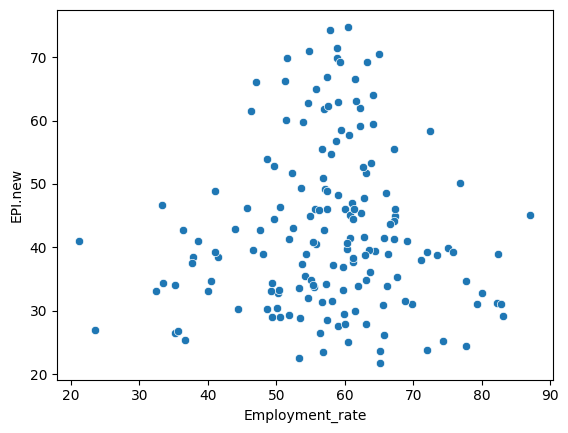

In [82]:
sns.scatterplot(x = 'Employment_rate', y = 'EPI.new', data = merged_data)
plt.show()

In [83]:
merged_data[['Employment_rate', 'EPI.new']].corr()

,Employment_rate,EPI.new
Employment_rate,1.000000,0.018522
EPI.new,0.018522,1.000000


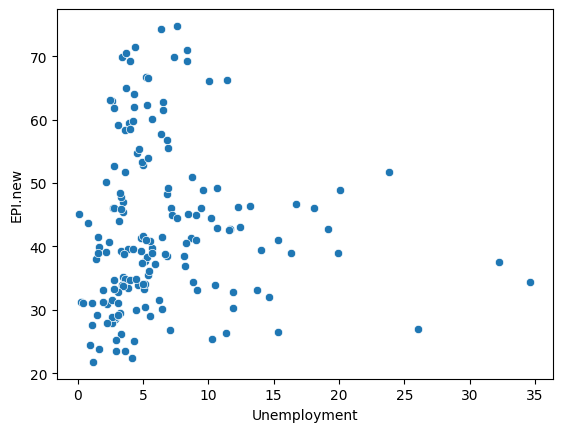

In [84]:
sns.scatterplot(x='Unemployment', y='EPI.new', data=merged_data)
plt.show()

In [85]:
merged_data[['Unemployment', 'EPI.new']].corr()

,Unemployment,EPI.new
Unemployment,1.000000,0.017362
EPI.new,0.017362,1.000000


#### Findings

Neither employment nor unemployment rates show a meaningful linear association with environmental performance.

The Pearson correlation between employment rate and EPI score is 0.019, while the correlation between unemployment rate and EPI score is 0.017. Both values are very close to zero, indicating little to no linear relationship with EPI in this dataset.

These results suggest that labor market indicators, when considered individually, are not strongly associated with differences in environmental performance across countries.

### 5.4 Urbanization and Environmental Performance

**Research Question:** How is urbanization associated with environmental performance, and does this relationship differ across environmental dimensions such as air quality, waste management, and environmental health?

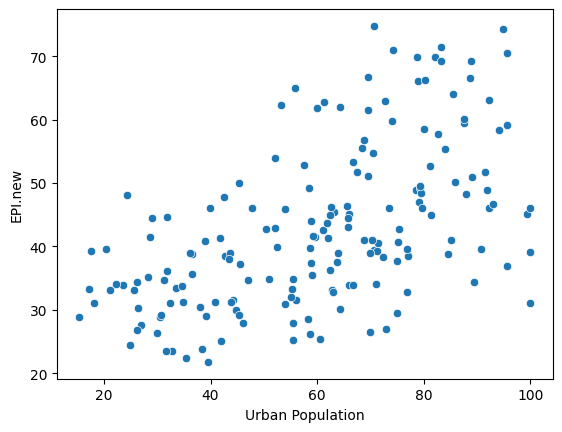

In [86]:
sns.scatterplot(x='Urban Population', y='EPI.new', data=merged_data)
plt.show()

In [87]:
merged_data[['Urban Population', 'EPI.new']].corr()

,Urban Population,EPI.new
Urban Population,1.000000,0.554904
EPI.new,0.554904,1.000000


In [88]:
merged_data[['Urban Population', 'AIR.new', 'WMG.new', 'HLT.new']].corr()

,Urban Population,AIR.new,WMG.new,HLT.new
Urban Population,1.000000,0.530993,0.564539,0.603519
AIR.new,0.530993,1.000000,0.594787,0.976988
WMG.new,0.564539,0.594787,1.000000,0.705151
HLT.new,0.603519,0.976988,0.705151,1.000000


#### Regional Differences in Environmental Performance

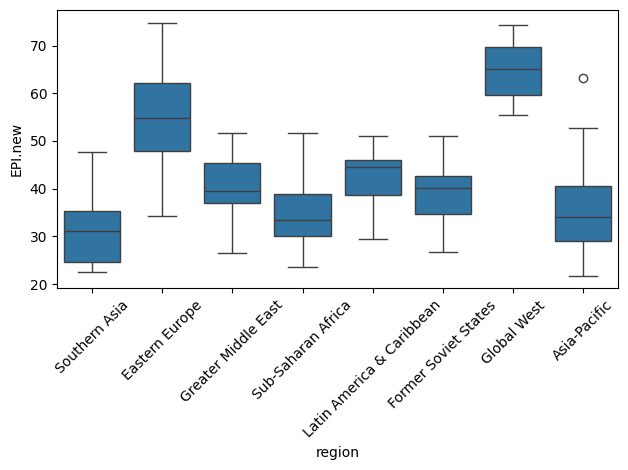

In [89]:
sns.boxplot(x='region', y='EPI.new', data = merged_data)
plt.xticks(rotation=45)
plt.tight_layout()

#### Findings

Urbanization shows a moderate positive association with environmental performance. The Pearson correlation between urban population share and EPI score is 0.555, suggesting that more urbanized countries tend to have higher environmental performance scores.

The relationship also varies across environmental dimensions. Urban population is positively correlated with air quality (r = 0.531), waste management (r = 0.565), and environmental health (r = 0.604), with the strongest association observed for environmental health.

Environmental performance also differs considerably across regions. The regional distributions show notably higher EPI scores in regions such as the Global West and Eastern Europe, while Southern Asia and Sub-Saharan Africa generally show lower scores. Considerable variation remains within several regions, indicating that regional classification alone does not fully explain differences in environmental performance.

### 5.5 Countries Performing Above or Below Economic Expectations

**Research Question:** Which countries perform substantially better or worse environmentally than their economic prosperity might suggest?

In [90]:
merged_data['log_GDP'] = np.log(merged_data['GDP'])
slope, intercept = np.polyfit(merged_data['log_GDP'], merged_data['EPI.new'], 1)

In [91]:
merged_data['Expected_EPI'] = (slope * merged_data['log_GDP']) + intercept

In [92]:
merged_data['Residual'] = merged_data['EPI.new'] - merged_data['Expected_EPI']

In [93]:
merged_data[['country', 'EPI.new', 'Expected_EPI', 'Residual']].sort_values(by = 'Residual', ascending = False).head(10)

,country,EPI.new,Expected_EPI,Residual
51,Estonia,74.79,52.600309,22.189691
168,United Kingdom,71.51,56.242677,15.267323
62,Greece,66.03,50.920954,15.109046
55,Finland,71.04,56.218656,14.821344
56,France,69.82,55.238574,14.581426
60,Germany,69.93,56.590328,13.339672
148,Spain,66.28,53.405419,12.874581
107,Mozambique,38.78,25.968930,12.811070
111,Netherlands,70.49,57.860069,12.629931
153,Sweden,69.20,56.726304,12.473696


In [94]:
merged_data[['country', 'EPI.new', 'Expected_EPI', 'Residual']].sort_values(by = 'Residual', ascending = True).head(10)

,country,EPI.new,Expected_EPI,Residual
67,Guyana,30.32,52.205108,-21.885108
97,Maldives,25.06,46.720213,-21.660213
11,Bahrain,31.05,52.214821,-21.164821
173,Viet Nam,23.82,39.541440,-15.721440
23,Brunei Darussalam,37.71,52.968243,-15.258243
75,Iraq,26.55,41.282423,-14.732423
137,Saudi Arabia,38.74,53.444488,-14.704488
142,Singapore,46.06,60.209179,-14.149179
170,Uruguay,36.91,50.831562,-13.921562
85,Kuwait,39.19,52.906126,-13.716126


In [95]:
top_positive = merged_data.sort_values(by='Residual', ascending = False).head(3)
top_negative = merged_data.sort_values(by='Residual', ascending = True).head(2)

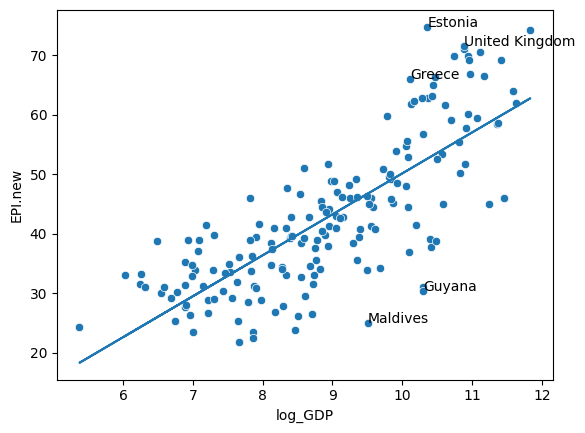

In [96]:
sns.scatterplot(x='log_GDP', y='EPI.new', data=merged_data)
plt.plot(merged_data['log_GDP'], merged_data['Expected_EPI'])
for index, row in top_positive.iterrows():
    plt.annotate(row['country'], (row['log_GDP'], row['EPI.new']))
for index, row in top_negative.iterrows():
    plt.annotate(row['country'], (row['log_GDP'], row['EPI.new']))

#### Findings

The residual analysis highlights countries whose environmental performance differs substantially from what would be expected based on their economic prosperity.

Estonia shows the largest positive residual, with an EPI score approximately 22 points higher than predicted by the relationship between log GDP and EPI. The United Kingdom and Greece also perform notably above their expected levels.

In contrast, Guyana and Maldives show the largest negative residuals, with EPI scores approximately 22 points below their predicted values.

These results show that economic prosperity alone does not fully explain environmental performance. Countries with similar economic conditions can still differ considerably in their environmental outcomes.

### 5.6 Overall Socioeconomic Relationships

**Research Question:** Which socioeconomic indicators show the strongest relationships with environmental performance?

In [97]:
merged_data[['log_GDP', 'Secondary_enrollment', 'Employment_rate', 'Unemployment', 'Urban Population', 'EPI.new']].corr()

,log_GDP,Secondary_enrollment,Employment_rate,Unemployment,Urban Population,EPI.new
log_GDP,1.000000,0.748898,0.036290,-0.032373,0.674137,0.776536
Secondary_enrollment,0.748898,1.000000,-0.088419,0.167646,0.525497,0.632583
Employment_rate,0.036290,-0.088419,1.000000,-0.606979,0.022838,0.018522
Unemployment,-0.032373,0.167646,-0.606979,1.000000,0.065806,0.017362
Urban Population,0.674137,0.525497,0.022838,0.065806,1.000000,0.554904
EPI.new,0.776536,0.632583,0.018522,0.017362,0.554904,1.000000


#### Findings

Among the socioeconomic indicators examined, log-transformed GDP shows the strongest positive relationship with environmental performance (r = 0.777).

Secondary school enrollment also shows a relatively strong positive relationship with EPI (r = 0.633), followed by urban population (r = 0.555).

In contrast, employment and unemployment rates show almost no linear relationship with EPI, with correlations close to zero.

Overall, economic prosperity, educational participation, and urbanization show stronger associations with environmental performance than labor market indicators in this dataset.

## 6. EDA Conclusion

This analysis explored how socioeconomic conditions are associated with environmental performance across countries.

Economic prosperity showed the strongest relationship with environmental performance. After applying a logarithmic transformation to GDP, the relationship with EPI became stronger and more linear (r = 0.777). Secondary school enrollment (r = 0.633) and urban population (r = 0.555) also showed notable positive associations with EPI.

In contrast, employment and unemployment rates showed almost no linear relationship with environmental performance.

Urbanization was also positively associated with multiple environmental dimensions, particularly environmental health, while regional comparisons revealed substantial differences in EPI distributions across world regions.

The residual analysis showed that economic prosperity does not fully explain environmental performance. Some countries performed substantially better or worse than expected based on their economic level, highlighting variation that cannot be captured by GDP alone.

Overall, the results suggest that environmental performance is associated with several socioeconomic factors, but no single indicator fully explains the differences observed across countries.

## 7. Predictive Modeling

**Research Question:** Can socioeconomic indicators be used to predict a country's environmental performance?

### 7.1 Feature and Target Selection

Five socioeconomic indicators were selected as features, while EPI score was defined as the target variable.

In [98]:
X = merged_data[['log_GDP', 'Secondary_enrollment', 'Urban Population', 'Employment_rate', 'Unemployment']]
y = merged_data['EPI.new']

### 7.2 Train-Test Split

The data was divided into training (80%) and testing (20%) sets to evaluate the model on unseen data.

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42)

In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(140, 5)
(36, 5)
(140,)
(36,)


### 7.3 Handling Missing Values

Missing values were identified in some of the selected features. Median imputation was used to handle these missing values. The imputer was fitted only on the training data and then applied to the test data to avoid data leakage.

In [101]:
X.isnull().sum()

log_GDP                  0
Secondary_enrollment    47
Urban Population         0
Employment_rate         10
Unemployment            10
dtype: int64

In [102]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

### 7.4 Linear Regression Model

A Linear Regression model was trained using the prepared training data and then used to predict EPI scores for the test set.

In [103]:
model = LinearRegression()

In [104]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 6.07, 0.08,-0.01, 0.02, 0.13]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-20.48
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[292.69,182.51,144.36, 48.77, 10.79]"


In [105]:
predictions = model.predict(X_test)

### 7.5 Model Evaluation

Model performance was evaluated using Mean Absolute Error (MAE), R², and a comparison between actual and predicted EPI scores.

In [106]:
mae = mean_absolute_error(y_test, predictions)
mae

6.357567516457922

In [107]:
r2 = r2_score(y_test, predictions)
r2

0.6657007586328141

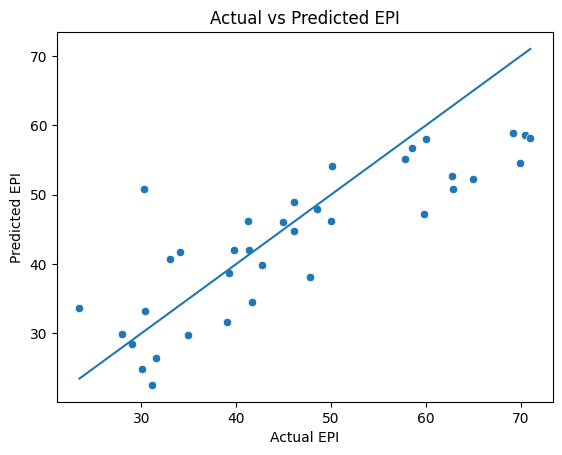

In [108]:
sns.scatterplot( x = y_test, y = predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual EPI')
plt.ylabel('Predicted EPI')
plt.title('Actual vs Predicted EPI')
plt.show()

#### Results

- **MAE:** 6.36
- **R²:** 0.666

The model's predictions differ from the actual EPI scores by approximately 6.36 points on average.

The R² score indicates that the model explains approximately 66.6% of the variation in EPI scores in the test data.

The Actual vs Predicted plot shows that the model captures the overall pattern in environmental performance, although some predictions deviate considerably from the actual values.

### 7.6 Random Forest Regression

A Random Forest Regressor was used as a non-linear alternative to Linear Regression to examine whether a more flexible model could improve EPI prediction.

In [109]:
rf_model = RandomForestRegressor(random_state = 40)

In [110]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",40
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [111]:
rf_predictions = rf_model.predict(X_test)

In [112]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

In [113]:
rf_r2 = r2_score(y_test, rf_predictions)

In [114]:
rf_mae, rf_r2

(5.533583333333333, 0.6949701282604793)

#### Random Forest Performance

- **MAE:** 5.53
- **R²:** 0.695

The Random Forest model achieved a lower MAE and a higher R² score than the Linear Regression model, indicating slightly better predictive performance on the test data.

#### Feature Importance

Feature importance was examined to understand which socioeconomic indicators contributed most to the Random Forest predictions.

In [115]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importance

,Feature,Importance
0,log_GDP,0.704570
1,Secondary_enrollment,0.073240
2,Urban Population,0.067297
3,Employment_rate,0.081198
4,Unemployment,0.073695


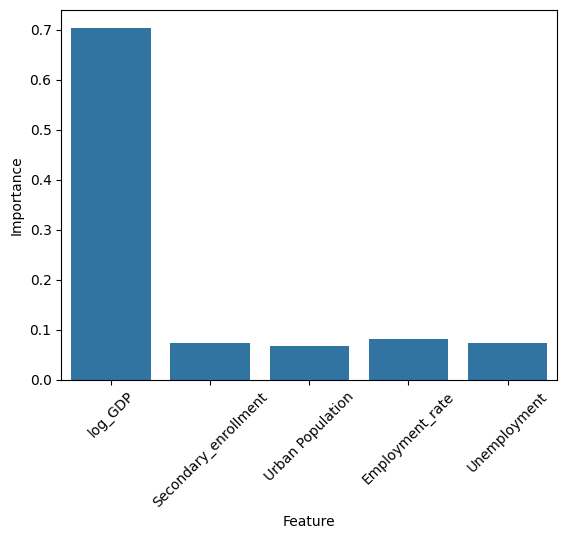

In [116]:
sns.barplot(x='Feature', y='Importance', data=feature_importance)
plt.xticks(rotation=45)
plt.show()

The results show that log GDP is by far the most important feature in the Random Forest model. The remaining socioeconomic indicators have considerably lower and relatively similar importance values.

#### Model Comparison

The performance of Linear Regression and Random Forest was compared using the same test data.

In [117]:
model_comparison = pd.DataFrame({'Linear Regression' : [mae, r2], 'Random Forest' : [rf_mae, rf_r2]}, index = ['MAE', 'R2'])
model_comparison

,Linear Regression,Random Forest
MAE,6.357568,5.533583
R2,0.665701,0.694970


Random Forest performed slightly better than Linear Regression, reducing the MAE from 6.36 to 5.53 and increasing R² from 0.666 to 0.695.

Overall, both models show that socioeconomic indicators can be used to predict environmental performance to some extent, with Random Forest providing the better performance of the two models tested.

### 7.7 Gradient Boosting Regression
Gradient Boosting Regression was used as an additional non-linear model to evaluate whether a sequential boosting approach could improve EPI prediction compared with Linear Regression and Random Forest.

In [118]:
gb_model = GradientBoostingRegressor(random_state = 30)

In [119]:
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",30
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [120]:
gb_predictions = gb_model.predict(X_test)

In [121]:
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

In [122]:
print(gb_mae)
print(gb_r2)

5.688044277105828
0.6726335814698793


In [123]:
model_comparison['Gradient Boosting'] = [gb_mae, gb_r2]

In [124]:
model_comparison

,Linear Regression,Random Forest,Gradient Boosting
MAE,6.357568,5.533583,5.688044
R2,0.665701,0.694970,0.672634


#### Gradient Boosting Performance

- **MAE:** 5.69
- **R²:** 0.673

Gradient Boosting achieved a lower MAE than Linear Regression, but did not outperform Random Forest. Based on the current train-test split, Random Forest achieved the best performance among the three models.

### 7.8 Cross-Validation

To obtain a more reliable estimate of model performance, 5-fold cross-validation was applied to all three regression models.

In 5-fold cross-validation, the dataset is divided into five subsets. Each model is trained five times, using a different subset for validation in each iteration while the remaining four subsets are used for training. The final performance is evaluated using the average R² score across the five folds.

Pipelines were used to ensure that missing values were imputed separately within each training fold, preventing data leakage during cross-validation.

In [125]:
lr_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', LinearRegression())])

In [126]:
rf_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', RandomForestRegressor(random_state=40))])

In [127]:
gb_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')), ('model', GradientBoostingRegressor(random_state = 10))])

#### Model Evaluation Across Folds

Each pipeline was evaluated using 5-fold cross-validation with R² as the performance metric.

In [128]:
lr_cv_r2 = cross_val_score(lr_pipeline, X, y, scoring = 'r2', cv = 5)
lr_cv_r2

array([0.41552253, 0.61787062, 0.63206961, 0.65462413, 0.56633291])

In [129]:
lr_cv_r2.mean()

np.float64(0.5772839608998717)

In [130]:
rf_cv_r2 = cross_val_score(rf_pipeline, X, y, scoring = 'r2', cv = 5)
rf_cv_r2

array([0.30505844, 0.68173971, 0.74067062, 0.71229688, 0.6656907 ])

In [131]:
rf_cv_r2.mean()

np.float64(0.6210912711506911)

In [132]:
gb_cv_r2 = cross_val_score(gb_pipeline, X, y, scoring = 'r2', cv = 5)
gb_cv_r2

array([0.33836851, 0.65065647, 0.68925503, 0.6476273 , 0.55165921])

In [133]:
gb_cv_r2.mean()

np.float64(0.5755133043288942)

#### Cross-Validation Comparison

The mean R² scores across the five folds were compared to assess the overall predictive performance of the three models.

In [134]:
cv_comparison = pd.DataFrame({
    'Mean CV R2': [lr_cv_r2.mean(), rf_cv_r2.mean(), gb_cv_r2.mean()]}, index=[
    'Linear Regression',
    'Random Forest',
    'Gradient Boosting'
])
cv_comparison

,Mean CV R2
Linear Regression,0.577284
Random Forest,0.621091
Gradient Boosting,0.575513


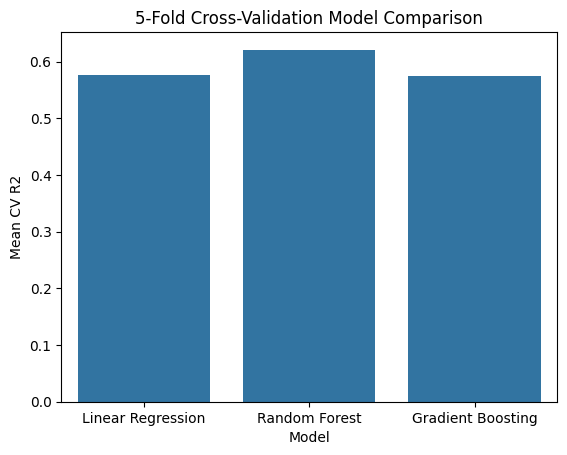

In [135]:
sns.barplot(x=cv_comparison.index, y='Mean CV R2', data=cv_comparison)
plt.xlabel('Model')
plt.ylabel('Mean CV R2')
plt.title('5-Fold Cross-Validation Model Comparison')
plt.show()

#### Cross-Validation Results

Five-fold cross-validation was used to evaluate model performance across multiple data splits.

Random Forest achieved the highest mean R² score (0.621), compared with Linear Regression (0.577) and Gradient Boosting (0.576). This indicates that Random Forest showed the strongest overall predictive performance among the three models.

The variation in performance across the individual folds also shows that model performance depends on the specific countries included in each validation set, highlighting the importance of evaluating models across multiple data splits rather than relying on a single train-test split.

### 7.9 Final Model Selection

Random Forest was selected as the final model because it achieved the best overall performance among the three models. It produced the lowest test MAE, the highest test R² score, and the highest mean R² score in 5-fold cross-validation.

The cross-validation results also suggest that its performance is not limited to a single train-test split, making Random Forest the most reliable model among those evaluated.

# 8. Explainable AI with SHAP

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the selected Random Forest model. It helps identify how each socioeconomic feature contributes to the model's predictions, both across the entire dataset and for individual countries.

In [136]:
explainer = shap.TreeExplainer(rf_model)

In [137]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [138]:
shap_values = explainer(X_test_df)
shap_values.shape

(36, 5)

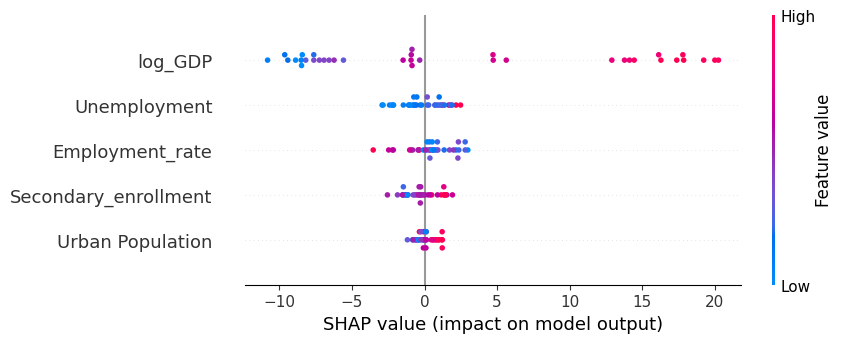

In [139]:
shap.plots.beeswarm(shap_values)

#### Global SHAP Analysis

The SHAP summary plot shows that `log_GDP` has the strongest overall influence on the Random Forest predictions. Higher log GDP values generally push predicted EPI scores upward, while lower values tend to reduce the predictions.

The remaining socioeconomic indicators have smaller effects on the model's predictions. Employment and unemployment show some variation in their contributions, while secondary enrollment and urban population generally have more limited effects.

These SHAP values describe how the Random Forest model uses the features when making predictions and should not be interpreted as evidence of causal relationships.

#### Local SHAP Explanation: Bolivia

To illustrate how the model generates an individual prediction, SHAP values were examined for Bolivia. The waterfall plot shows how each socioeconomic feature moves the prediction away from the model's baseline value.

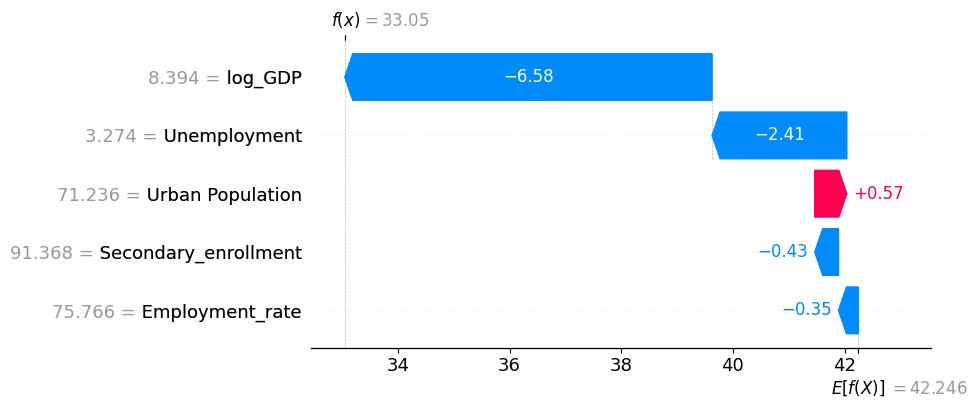

In [140]:
shap.plots.waterfall(shap_values[0])

The Random Forest model predicted an EPI score of approximately **33.05** for Bolivia, compared with its actual EPI score of **39.25**.

The SHAP explanation shows that `log_GDP` had the strongest negative contribution to the prediction, reducing the predicted EPI by approximately 6.58 points. Unemployment also contributed negatively, while urban population had a small positive contribution. Overall, the model underestimated Bolivia's actual environmental performance by approximately **6.20 EPI points**.

This example demonstrates how SHAP can explain not only which features are important globally, but also how individual feature values contribute to a specific country's prediction.

### SHAP Analysis Summary

The SHAP analysis provided additional insight into how the selected Random Forest model generates its predictions. At the global level, `log_GDP` was the dominant feature, with higher values generally contributing to higher predicted EPI scores. The remaining socioeconomic indicators had smaller and more variable effects.

The local explanation for Bolivia demonstrated how these relationships can differ for an individual country, with each feature contributing differently to the final prediction.

Overall, SHAP improves the interpretability of the model by showing both the overall importance and direction of feature effects and the factors behind individual predictions. These explanations reflect the behavior of the predictive model and should not be interpreted as causal relationships.

# 9. Conclusion and Limitations

## 9.1 Conclusion

The analysis revealed a clear relationship between socioeconomic development and environmental performance, although the strength of this relationship varied across the indicators examined. Economic prosperity showed the strongest and most consistent association with EPI, with `log_GDP` emerging as the leading indicator throughout the correlation analysis, Random Forest feature importance, and SHAP analysis. Educational participation also showed a notable positive relationship with environmental performance, although its close relationship with economic prosperity makes these factors difficult to consider entirely independently. Urbanization showed a moderate positive association with overall EPI and with specific environmental dimensions, including air quality, waste management, and environmental health. In contrast, employment and unemployment rates showed very weak direct linear relationships with EPI.

The country-level residual analysis further demonstrated that economic prosperity alone cannot fully explain environmental performance. Several countries performed substantially above or below the EPI level expected from their economic prosperity. These differences do not necessarily indicate whether a country's environmental performance is inherently good or bad, but rather how it compares with the level expected based on economic prosperity. This suggests that other factors beyond the socioeconomic indicators examined in this study may also contribute to differences in environmental performance across countries.

The predictive modeling results showed that the selected socioeconomic indicators can predict environmental performance to a meaningful extent. Although Linear Regression, Random Forest, and Gradient Boosting produced relatively similar results, Random Forest achieved the best overall performance, with the lowest test MAE (5.53), the highest test R² (0.695), and the highest mean cross-validation R² (0.621). SHAP analysis further supported the importance of economic prosperity in the model, identifying `log_GDP` as the dominant contributor to its predictions. Overall, the findings suggest that socioeconomic development is meaningfully associated with environmental performance, while also showing that environmental outcomes cannot be fully explained or predicted by socioeconomic conditions alone.

## 9.2 Limitations

Several limitations should be considered when interpreting the results of this study. First, combining socioeconomic and environmental datasets from different sources created challenges related to country coverage and missing values. Some indicators were not available for all countries, particularly secondary school enrollment, and median imputation was therefore used to handle missing observations. While this allowed more countries to remain in the analysis, the imputed values do not represent directly observed data.

The analysis was also based on a relatively small country-level dataset and a limited set of socioeconomic indicators. Environmental performance is likely associated with many additional factors that were not included in the models, such as environmental policies, energy systems, industrial structure, governance, and geographical conditions. This may partly explain why the predictive models could not account for all variation in EPI scores.

Finally, the relationships identified in this study should not be interpreted as causal. Correlation, feature importance, and SHAP values describe statistical relationships and model behavior, but they do not demonstrate that changes in a socioeconomic indicator directly cause changes in environmental performance. The results should therefore be interpreted as evidence of associations rather than causal effects.